# Fintech Customer Analytics & Risk Assessment
**Objective:** Customer growth, loan risk, digital engagement, product adoption, and acquisition channel performance.  
**Technologies:** Python · Pandas · NumPy · Matplotlib · Seaborn

## 1. Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
PALETTE   = ['#1f4e79', '#2e75b6', '#5ba3d9', '#a9c8e8', '#d6e9f7']
ACCENT    = '#e63946'
sns.set_theme(style='whitegrid', palette=PALETTE, font='DejaVu Sans')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'axes.labelsize': 11})

RAW_PATH   = 'dataset.xlsx'          # adjust if needed
CLEAN_PATH = 'fintech_cleaned.csv'

raw = pd.read_excel(RAW_PATH)
print(f'Shape: {raw.shape}  |  Columns: {raw.shape[1]}')
raw.head(3)

Shape: (508, 44)  |  Columns: 44


,Customer_ID,Full_Name,NIC_Number,Gender,Date_of_Birth,Age,District,Province,Urban_Rural,Customer_Segment,...,PEP_Flag,Has_Fixed_Deposit,FD_Amount,Has_Insurance,Has_Mobile_Wallet,Number_of_Products,Acquisition_Channel,Referral_Source,Last_Campaign_Response,Promo_Code_Used
0,FSL-0001,Mark Johnson,808614657V,Female,1980-12-26,43,Kandy,Central,Suburban,Regular,...,No,No,NaN,No,Yes,2,Referral,Friend,Responded,Yes
1,FSL-0002,Deborah Phillips,718478527V,Female,1971-12-13,52,Badulla,Uva,Urban,Starter,...,No,No,NaN,No,Yes,2,Referral,Family,Ignored,No
2,FSL-0003,Charles Phillips,933515010V,Male,1993-12-17,30,Kandy,Central,Suburban,Regular,...,No,Yes,1166599.45,No,No,3,Agent,Colleague,Responded,No


## 2. Data Cleaning

In [2]:
df = raw.copy()

# ── 2.1 Standardise categoricals ──────────────────────────────────────────
df['Account_Status'] = (
    df['Account_Status'].str.strip().str.title()
    .replace({'Active ': 'Active', 'Inactive': 'Inactive', 'Suspended': 'Suspended'})
)

gender_map = {'Male': 'Male', 'M': 'Male', 'male': 'Male', 'MALE': 'Male',
              'Female': 'Female', 'F': 'Female', 'female': 'Female', 'FEMALE': 'Female', 'f': 'Female'}
df['Gender'] = df['Gender'].map(gender_map)

# ── 2.2 Fill logical NaNs ─────────────────────────────────────────────────
# Customers without loans: fill string/numeric fields; leave date cols as NaT
no_loan_mask = df['Has_Loan'].fillna('No').str.strip().str.lower() == 'no'
str_loan_cols = ['Loan_Type','Loan_Repayment_Status']
num_loan_cols = ['Loan_Amount','Loan_Tenure_Months','Monthly_Repayment_Amount','Outstanding_Loan_Balance']
df.loc[no_loan_mask, str_loan_cols] = df.loc[no_loan_mask, str_loan_cols].fillna('None')
df.loc[no_loan_mask, num_loan_cols] = df.loc[no_loan_mask, num_loan_cols].fillna(0)

# FD Amount 0 for non-FD holders
df['FD_Amount'] = np.where(df['Has_Fixed_Deposit'] == 'No', 0, df['FD_Amount'])

# Referral source: 'Unknown' for non-referral channels
df['Referral_Source'] = np.where(
    df['Acquisition_Channel'] != 'Referral', 'N/A',
    df['Referral_Source'].fillna('Unknown')
)

# ── 2.3 Impute small numeric gaps with median ──────────────────────────────
for col in ['Savings_Balance', 'Monthly_Deposit_Avg']:
    df[col].fillna(df[col].median(), inplace=True)

# ── 2.4 Fill remaining string NaNs ────────────────────────────────────────
df['Customer_Segment'].fillna('Unknown', inplace=True)
df['District'].fillna('Unknown', inplace=True)
df['Full_Name'].fillna('N/A', inplace=True)
df['KYC_Status'].fillna('Pending', inplace=True)

# ── 2.5 Enforce dtypes ────────────────────────────────────────────────────
date_cols = ['Date_of_Birth', 'Account_Open_Date', 'Loan_Start_Date',
             'Last_Login_Date', 'KYC_Last_Updated']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['Has_Loan']               = df['Has_Loan'].str.strip().str.title()
df['Mobile_App_User']        = df['Mobile_App_User'].str.strip().str.title()
df['Has_Fixed_Deposit']      = df['Has_Fixed_Deposit'].str.strip().str.title()
df['Has_Insurance']          = df['Has_Insurance'].str.strip().str.title()
df['Has_Mobile_Wallet']      = df['Has_Mobile_Wallet'].str.strip().str.title()
df['Push_Notification_Enabled'] = df['Push_Notification_Enabled'].str.strip().str.title()

# ── 2.6 Derived KPIs ──────────────────────────────────────────────────────
df['Debt_to_Savings_Ratio'] = np.where(
    df['Savings_Balance'] > 0,
    df['Outstanding_Loan_Balance'].astype(float) / df['Savings_Balance'],
    np.nan
)

df['Is_Defaulted']    = (df['Loan_Repayment_Status'] == 'Defaulted').astype(int)
df['Is_Delayed']      = (df['Loan_Repayment_Status'] == 'Delayed').astype(int)
df['Is_App_User']     = (df['Mobile_App_User'] == 'Yes').astype(int)
df['Days_Since_Login']= (pd.Timestamp.today() - df['Last_Login_Date']).dt.days

# Loan-to-Income proxy (monthly repayment / deposit avg)
df['Loan_Income_Ratio'] = np.where(
    df['Monthly_Deposit_Avg'] > 0,
    df['Monthly_Repayment_Amount'].astype(float) / df['Monthly_Deposit_Avg'],
    np.nan
)

# ── 2.7 Remove duplicates ─────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset='Customer_ID', keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Duplicates removed: {before - len(df)}')

# ── 2.8 Export cleaned file ───────────────────────────────────────────────
df.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned dataset saved → {CLEAN_PATH}  |  Shape: {df.shape}')

# ── 2.9 Cleaning summary ──────────────────────────────────────────────────
missing_after = df.isnull().sum()
missing_after[missing_after > 0]

Duplicates removed: 8
Cleaned dataset saved → fintech_cleaned.csv  |  Shape: (500, 50)


Full_Name                     8
District                      5
Customer_Segment              5
Savings_Balance               6
Monthly_Deposit_Avg           6
Has_Loan                      5
Loan_Type                     2
Loan_Amount                   3
Loan_Tenure_Months            2
Monthly_Repayment_Amount      2
Loan_Repayment_Status         2
Loan_Start_Date             280
Outstanding_Loan_Balance      2
Last_Login_Date             168
KYC_Status                    7
Debt_to_Savings_Ratio        12
Days_Since_Login            168
Loan_Income_Ratio             8
dtype: int64

## 3. Exploratory Data Analysis

### 3.1 Customer Demographics

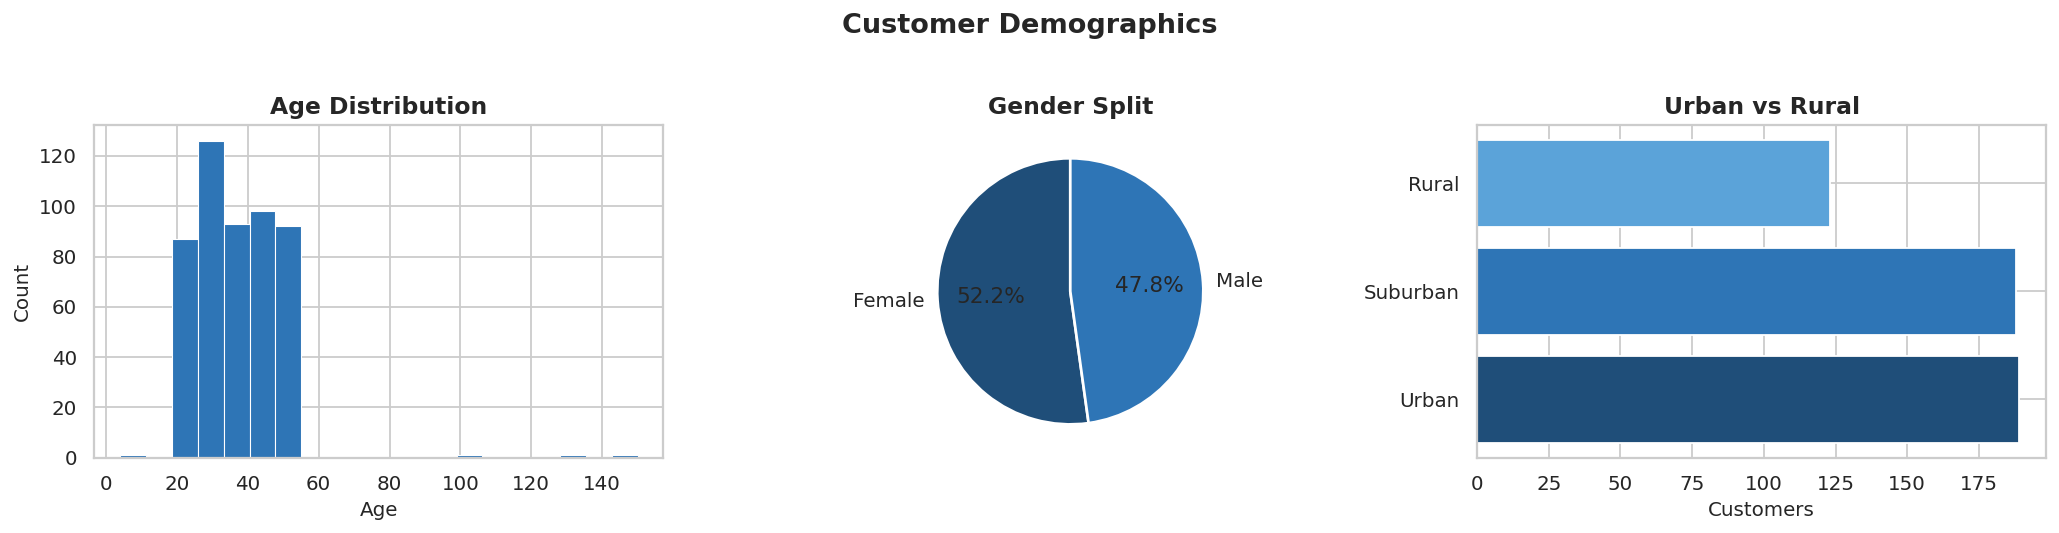

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(df['Age'], bins=20, color=PALETTE[1], edgecolor='white', linewidth=0.6)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

# Gender
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=PALETTE[:2], startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Gender Split')

# Urban / Rural
ur = df['Urban_Rural'].value_counts()
axes[2].barh(ur.index, ur.values, color=PALETTE[:3])
axes[2].set_title('Urban vs Rural')
axes[2].set_xlabel('Customers')

plt.suptitle('Customer Demographics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 3.2 Customer Segmentation

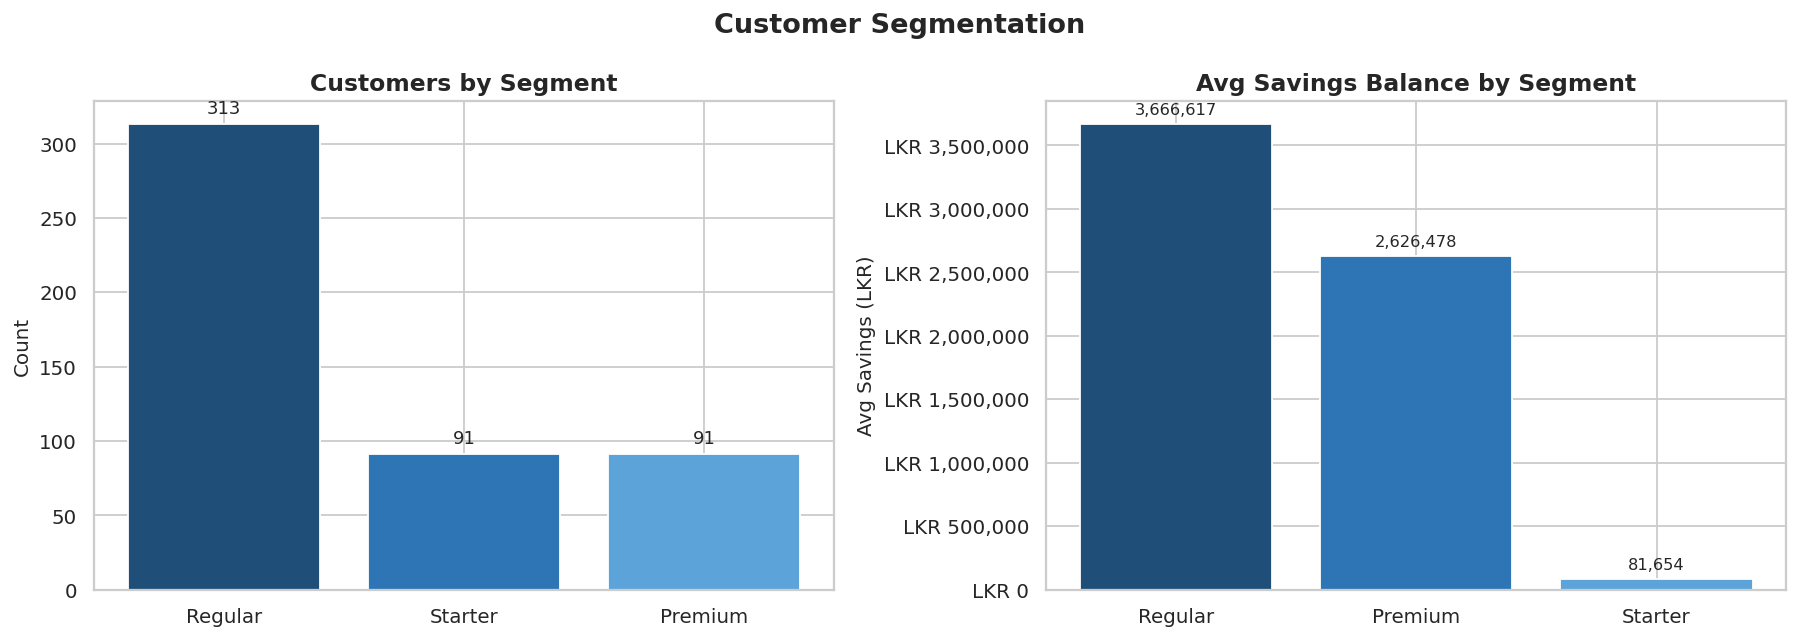

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment count
seg = df['Customer_Segment'].value_counts()
bars = axes[0].bar(seg.index, seg.values, color=PALETTE[:len(seg)], edgecolor='white')
axes[0].bar_label(bars, padding=4, fontsize=10)
axes[0].set_title('Customers by Segment')
axes[0].set_ylabel('Count')

# Avg savings per segment
seg_savings = df.groupby('Customer_Segment')['Savings_Balance'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(seg_savings.index, seg_savings.values, color=PALETTE[:len(seg_savings)], edgecolor='white')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'LKR {x:,.0f}'))
axes[1].set_title('Avg Savings Balance by Segment')
axes[1].set_ylabel('Avg Savings (LKR)')
axes[1].bar_label(bars2, labels=[f'{v:,.0f}' for v in seg_savings.values], padding=4, fontsize=9)

plt.suptitle('Customer Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.3 Account Status & Tenure

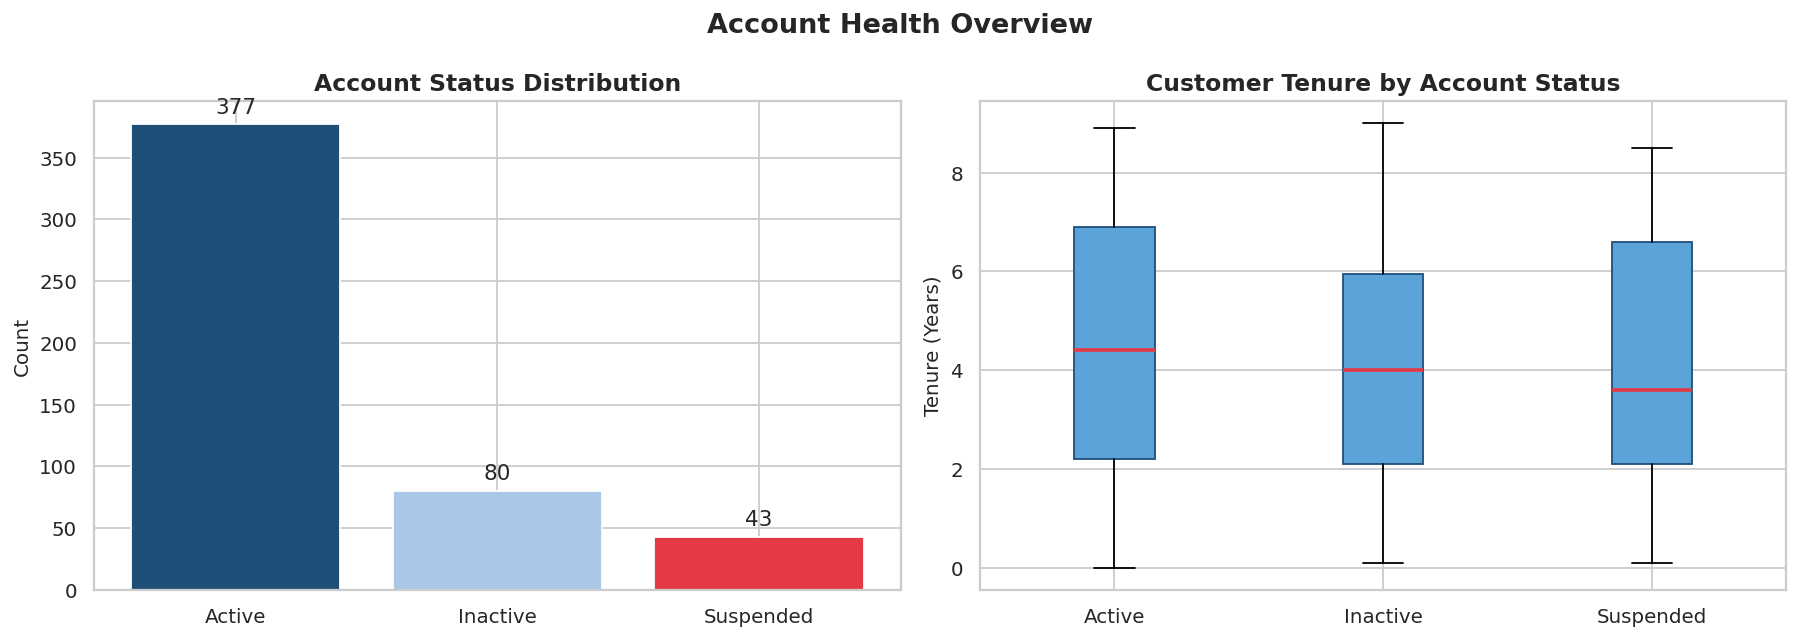

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

status = df['Account_Status'].value_counts()
colors_status = [PALETTE[0] if s == 'Active' else ACCENT if s == 'Suspended' else PALETTE[3] for s in status.index]
axes[0].bar(status.index, status.values, color=colors_status, edgecolor='white')
axes[0].bar_label(axes[0].containers[0], padding=4)
axes[0].set_title('Account Status Distribution')
axes[0].set_ylabel('Count')

axes[1].boxplot(
    [df.loc[df['Account_Status']==s, 'Customer_Tenure_Years'].dropna() for s in status.index],
    labels=status.index, patch_artist=True,
    boxprops=dict(facecolor=PALETTE[2], color=PALETTE[0]),
    medianprops=dict(color=ACCENT, linewidth=2)
)
axes[1].set_title('Customer Tenure by Account Status')
axes[1].set_ylabel('Tenure (Years)')

plt.suptitle('Account Health Overview', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Loan Portfolio & Risk Assessment

### 4.1 Loan Type & Repayment Distribution

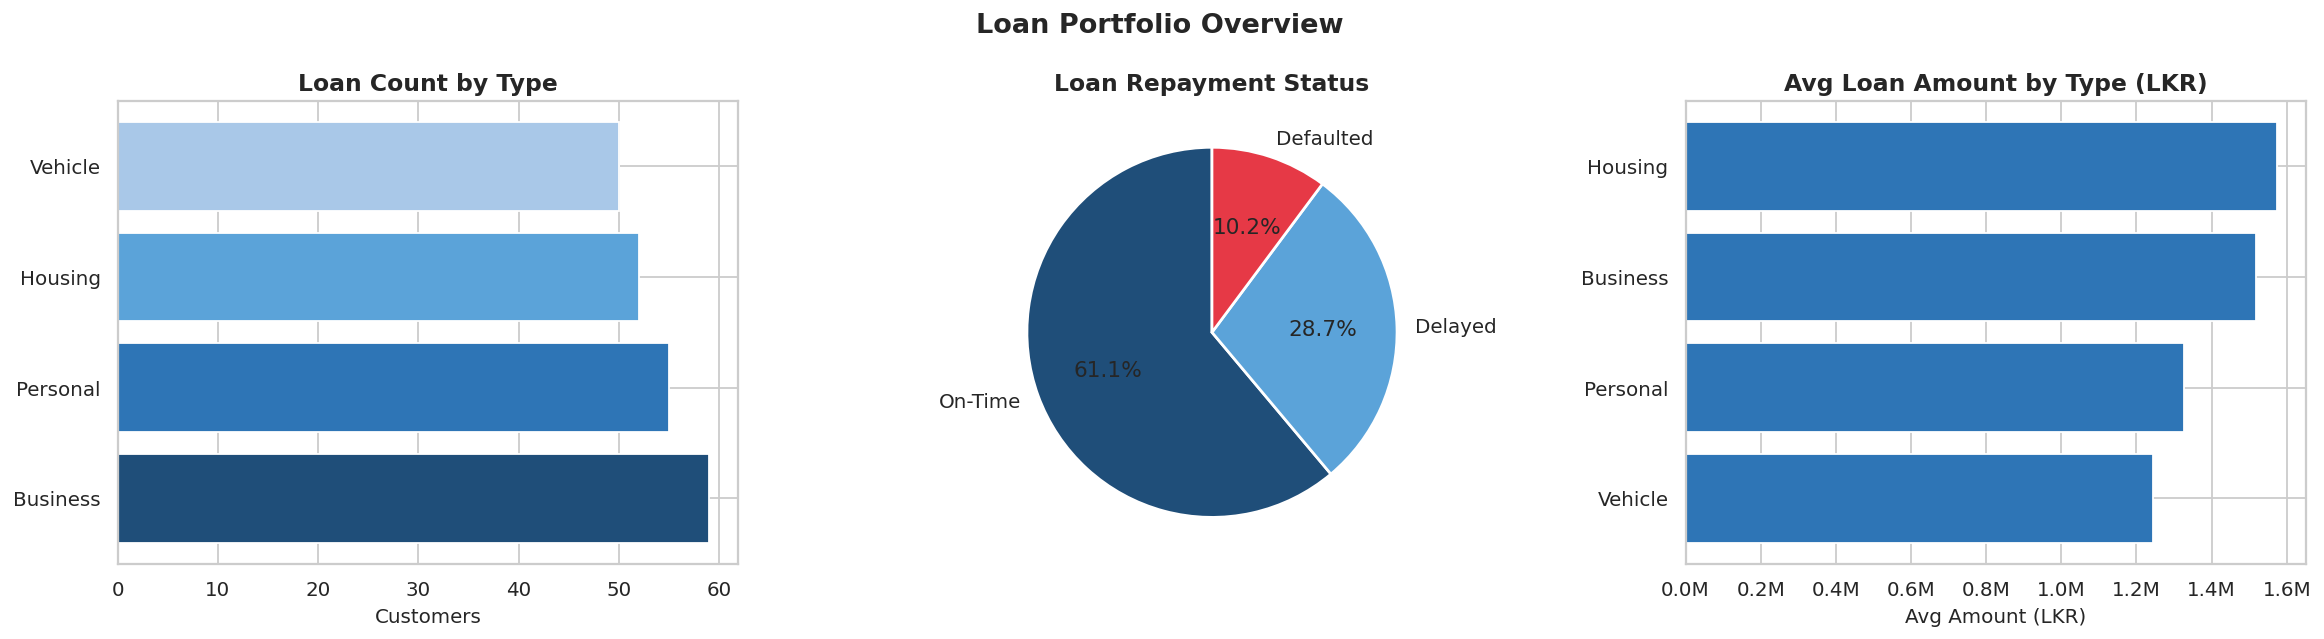

Total Loan Book     : LKR     305,038,129
Total Outstanding   : LKR     165,750,303
Default Rate        : 10.1%
Delayed Rate        : 28.4%


In [6]:
loan_df = df[df['Has_Loan'] == 'Yes'].copy()
loan_df['Outstanding_Loan_Balance'] = pd.to_numeric(loan_df['Outstanding_Loan_Balance'], errors='coerce')
loan_df['Loan_Amount']              = pd.to_numeric(loan_df['Loan_Amount'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loan type count
lt = loan_df['Loan_Type'].value_counts()
axes[0].barh(lt.index, lt.values, color=PALETTE[:len(lt)])
axes[0].set_title('Loan Count by Type')
axes[0].set_xlabel('Customers')

# Repayment status
rs = loan_df['Loan_Repayment_Status'].value_counts()
clrs = {s: (PALETTE[0] if s=='On-Time' else ACCENT if s=='Defaulted' else PALETTE[2]) for s in rs.index}
axes[1].pie(rs, labels=rs.index, autopct='%1.1f%%',
            colors=[clrs[k] for k in rs.index],
            wedgeprops={'edgecolor':'white','linewidth':1.5}, startangle=90)
axes[1].set_title('Loan Repayment Status')

# Avg loan amount by type
avg_loan = loan_df.groupby('Loan_Type')['Loan_Amount'].mean().sort_values()
axes[2].barh(avg_loan.index, avg_loan.values, color=PALETTE[1])
axes[2].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[2].set_title('Avg Loan Amount by Type (LKR)')
axes[2].set_xlabel('Avg Amount (LKR)')

plt.suptitle('Loan Portfolio Overview', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# KPIs
total_loan_book   = loan_df['Loan_Amount'].sum()
total_outstanding = loan_df['Outstanding_Loan_Balance'].sum()
default_rate      = (loan_df['Loan_Repayment_Status'] == 'Defaulted').mean() * 100
delayed_rate      = (loan_df['Loan_Repayment_Status'] == 'Delayed').mean() * 100

print(f'Total Loan Book     : LKR {total_loan_book:>15,.0f}')
print(f'Total Outstanding   : LKR {total_outstanding:>15,.0f}')
print(f'Default Rate        : {default_rate:.1f}%')
print(f'Delayed Rate        : {delayed_rate:.1f}%')

### 4.2 Debt-to-Savings Ratio Analysis

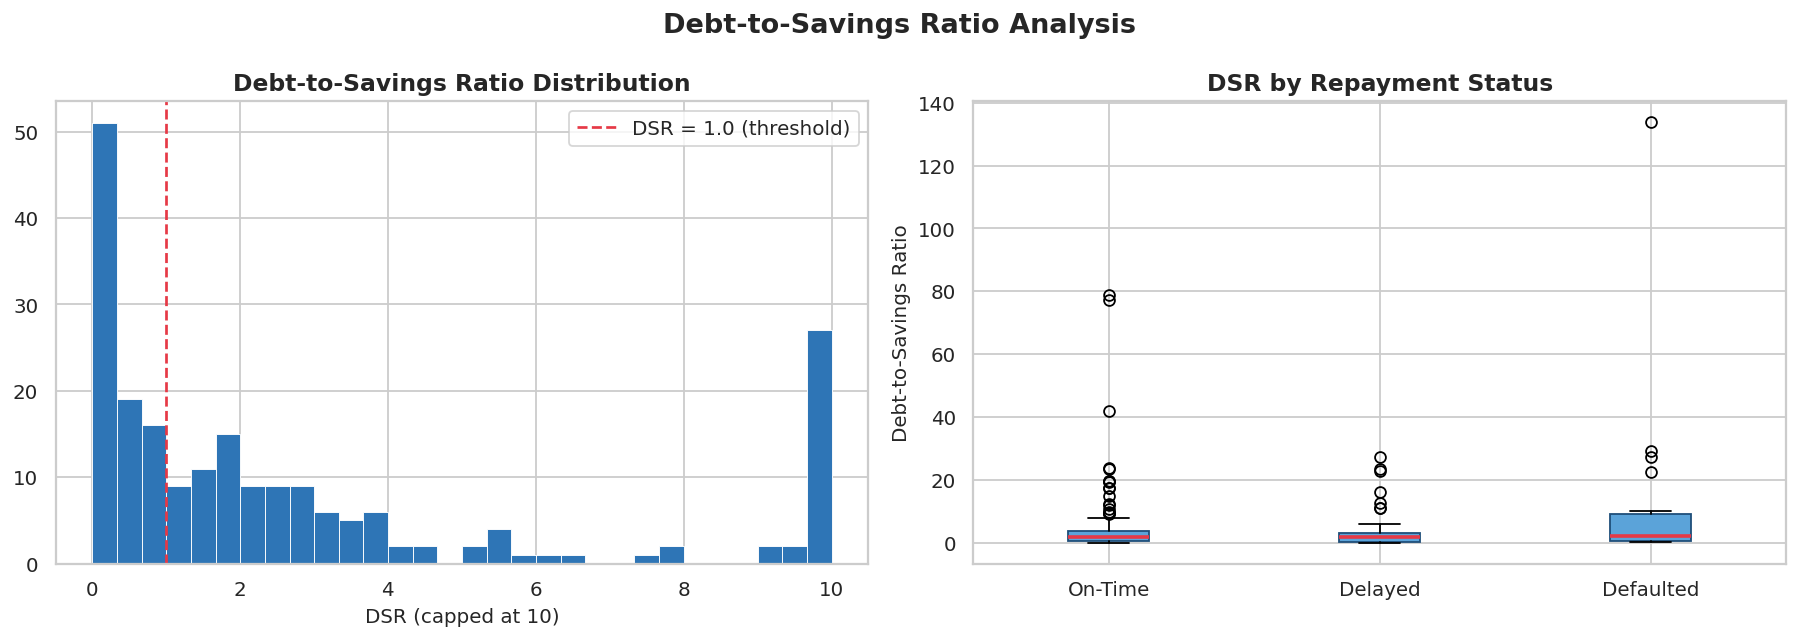

High-risk customers (DSR > 2): 93 (43.9% of loan holders)


In [7]:
dsr = loan_df.dropna(subset=['Debt_to_Savings_Ratio'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DSR distribution
axes[0].hist(dsr['Debt_to_Savings_Ratio'].clip(upper=10), bins=30,
             color=PALETTE[1], edgecolor='white', linewidth=0.5)
axes[0].axvline(1, color=ACCENT, linestyle='--', linewidth=1.5, label='DSR = 1.0 (threshold)')
axes[0].set_title('Debt-to-Savings Ratio Distribution')
axes[0].set_xlabel('DSR (capped at 10)')
axes[0].legend()

# DSR by repayment status
order = ['On-Time', 'Delayed', 'Defaulted']
dsr_order = [dsr.loc[dsr['Loan_Repayment_Status']==s, 'Debt_to_Savings_Ratio'].dropna() for s in order]
bp = axes[1].boxplot(dsr_order, labels=order, patch_artist=True,
                     boxprops=dict(facecolor=PALETTE[2], color=PALETTE[0]),
                     medianprops=dict(color=ACCENT, linewidth=2))
axes[1].set_title('DSR by Repayment Status')
axes[1].set_ylabel('Debt-to-Savings Ratio')

plt.suptitle('Debt-to-Savings Ratio Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

high_risk = (dsr['Debt_to_Savings_Ratio'] > 2).sum()
print(f'High-risk customers (DSR > 2): {high_risk} ({high_risk/len(dsr)*100:.1f}% of loan holders)')

### 4.3 Default Risk by Segment & Province

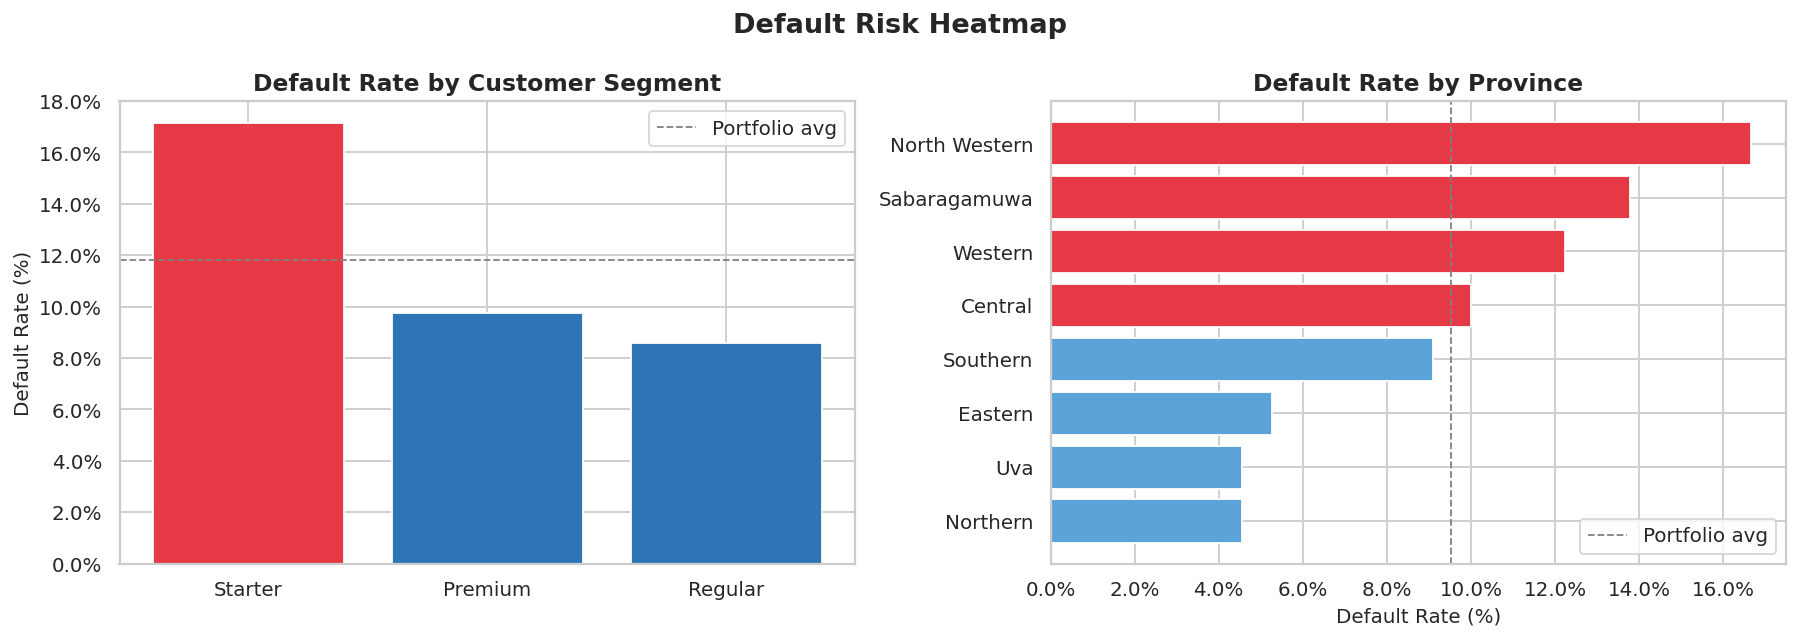

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_default = (
    loan_df.groupby('Customer_Segment')['Is_Defaulted'].mean() * 100
).sort_values(ascending=False)
colors_d = [ACCENT if v > seg_default.mean() else PALETTE[1] for v in seg_default.values]
axes[0].bar(seg_default.index, seg_default.values, color=colors_d, edgecolor='white')
axes[0].axhline(seg_default.mean(), linestyle='--', color='grey', linewidth=1, label='Portfolio avg')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Default Rate by Customer Segment')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend()

prov_default = (
    loan_df.groupby('Province')['Is_Defaulted'].mean() * 100
).sort_values(ascending=True)
axes[1].barh(prov_default.index, prov_default.values,
             color=[ACCENT if v > prov_default.mean() else PALETTE[2] for v in prov_default.values])
axes[1].axvline(prov_default.mean(), linestyle='--', color='grey', linewidth=1, label='Portfolio avg')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Default Rate by Province')
axes[1].set_xlabel('Default Rate (%)')
axes[1].legend()

plt.suptitle('Default Risk Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Digital Engagement

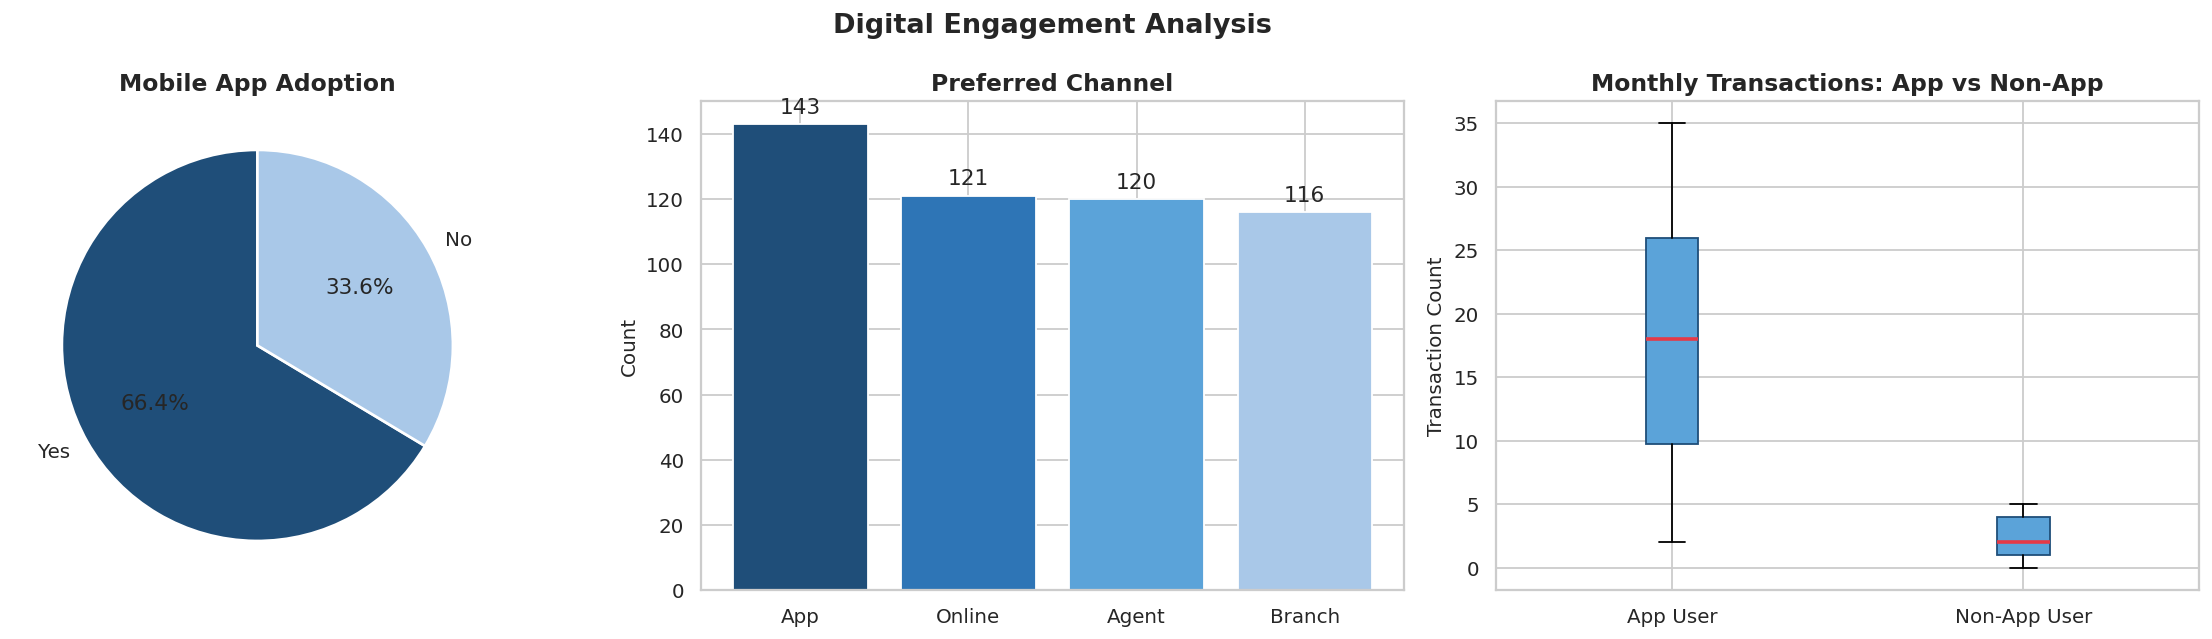

App User Avg Txns  : 18.1
Non-App Avg Txns   : 2.3
Push Notif Enabled : 56.2%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# App adoption
app = df['Mobile_App_User'].value_counts()
axes[0].pie(app, labels=app.index, autopct='%1.1f%%', colors=[PALETTE[0], PALETTE[3]],
            wedgeprops={'edgecolor':'white','linewidth':1.5}, startangle=90)
axes[0].set_title('Mobile App Adoption')

# Preferred channel
ch = df['Preferred_Channel'].value_counts()
axes[1].bar(ch.index, ch.values, color=PALETTE[:len(ch)], edgecolor='white')
axes[1].bar_label(axes[1].containers[0], padding=4)
axes[1].set_title('Preferred Channel')
axes[1].set_ylabel('Count')

# Monthly transaction count by app usage
app_yes = df.loc[df['Mobile_App_User']=='Yes', 'Monthly_Transaction_Count']
app_no  = df.loc[df['Mobile_App_User']=='No',  'Monthly_Transaction_Count']
axes[2].boxplot([app_yes, app_no], labels=['App User', 'Non-App User'], patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], color=PALETTE[0]),
                medianprops=dict(color=ACCENT, linewidth=2))
axes[2].set_title('Monthly Transactions: App vs Non-App')
axes[2].set_ylabel('Transaction Count')

plt.suptitle('Digital Engagement Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"App User Avg Txns  : {app_yes.mean():.1f}")
print(f"Non-App Avg Txns   : {app_no.mean():.1f}")
print(f"Push Notif Enabled : {(df['Push_Notification_Enabled']=='Yes').mean()*100:.1f}%")

### 5.1 Inactive Customers (Days Since Login)

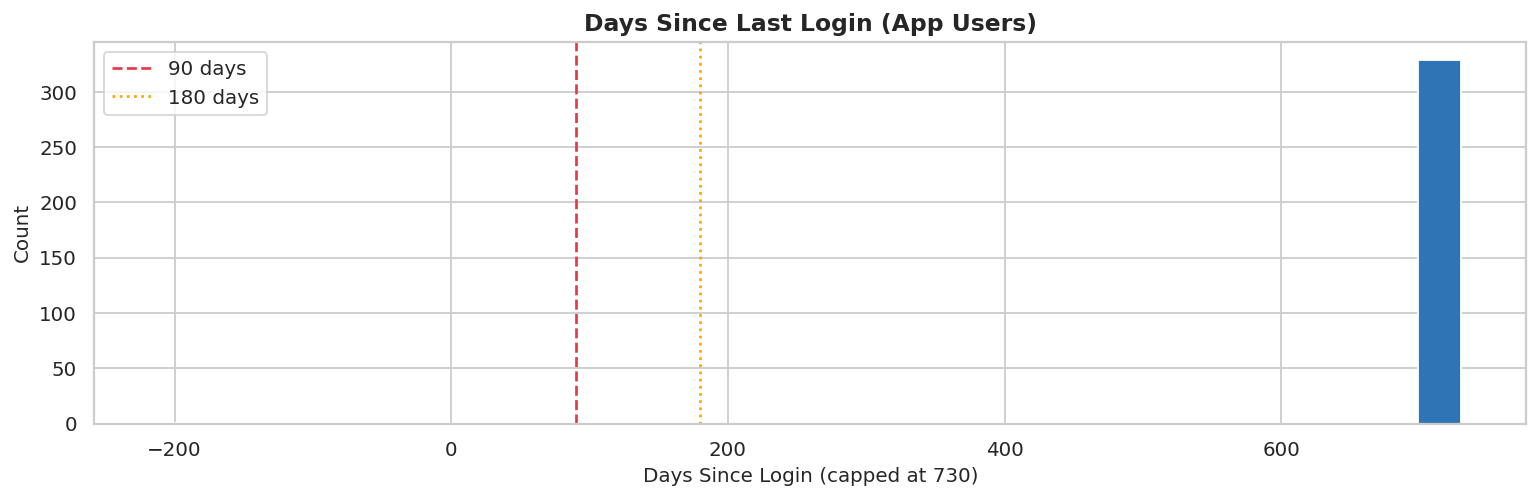

App users dormant >90 days  : 330
App users dormant >180 days : 330


In [10]:
active_app = df[df['Mobile_App_User'] == 'Yes'].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(active_app['Days_Since_Login'].dropna().clip(upper=730), bins=30,
        color=PALETTE[1], edgecolor='white')
ax.axvline(90,  linestyle='--', color=ACCENT, linewidth=1.5, label='90 days')
ax.axvline(180, linestyle=':',  color='orange', linewidth=1.5, label='180 days')
ax.set_title('Days Since Last Login (App Users)')
ax.set_xlabel('Days Since Login (capped at 730)')
ax.set_ylabel('Count')
ax.legend(); plt.tight_layout(); plt.show()

dormant_90  = (active_app['Days_Since_Login'] > 90).sum()
dormant_180 = (active_app['Days_Since_Login'] > 180).sum()
print(f'App users dormant >90 days  : {dormant_90}')
print(f'App users dormant >180 days : {dormant_180}')

## 6. Product Adoption

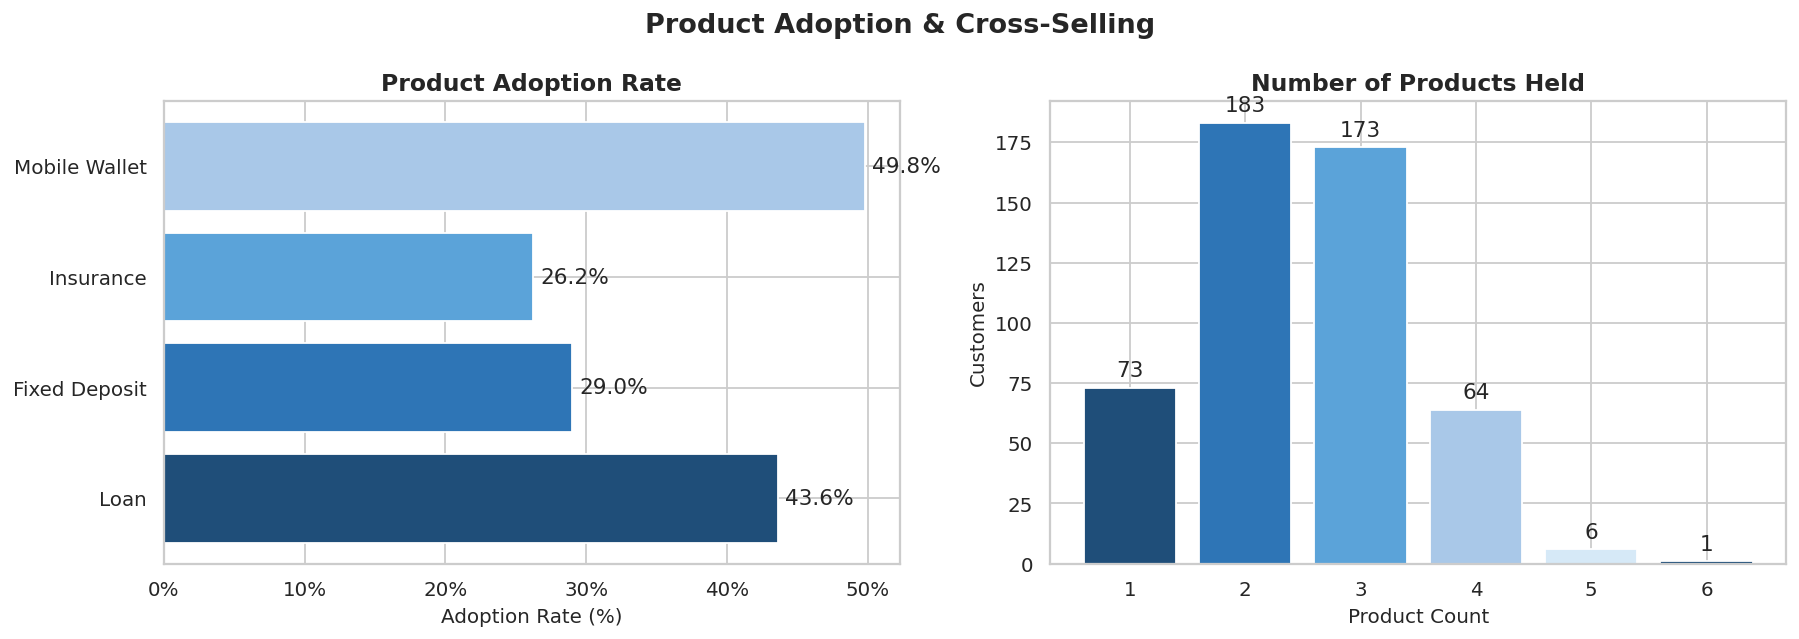

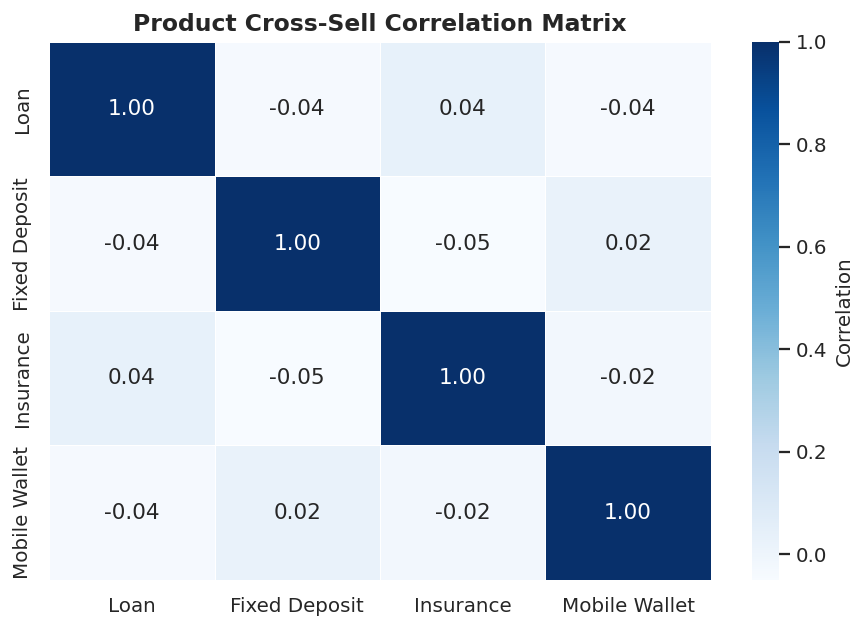

In [11]:
product_cols = ['Has_Loan', 'Has_Fixed_Deposit', 'Has_Insurance', 'Has_Mobile_Wallet']
product_rates = {col.replace('Has_','').replace('_',' '): (df[col]=='Yes').mean()*100
                 for col in product_cols}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(list(product_rates.keys()), list(product_rates.values()),
                    color=PALETTE[:4], edgecolor='white')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].bar_label(bars, labels=[f'{v:.1f}%' for v in product_rates.values()], padding=4)
axes[0].set_title('Product Adoption Rate')
axes[0].set_xlabel('Adoption Rate (%)')

prod_count = df['Number_of_Products'].value_counts().sort_index()
axes[1].bar(prod_count.index, prod_count.values, color=PALETTE[:len(prod_count)], edgecolor='white')
axes[1].bar_label(axes[1].containers[0], padding=4)
axes[1].set_title('Number of Products Held')
axes[1].set_xlabel('Product Count')
axes[1].set_ylabel('Customers')

plt.suptitle('Product Adoption & Cross-Selling', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# Cross-sell matrix
bool_cols = {col: (df[col]=='Yes') for col in product_cols}
bool_df   = pd.DataFrame(bool_cols)
bool_df.columns = [c.replace('Has_','').replace('_',' ') for c in product_cols]
corr = bool_df.astype(int).corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax.set_title('Product Cross-Sell Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Acquisition Channel Performance

Acquisition_Channel  Customers  Avg_Savings  Avg_Products  App_Adoption_Pct  Default_Rate_Pct
              Agent        117 6.458826e+05      2.606838         64.957265          2.564103
             Branch        123 8.274721e+05      2.544715         59.349593          4.878049
            Digital        131 8.451134e+06      2.404580         69.465649          5.343511
           Referral        129 7.628440e+05      2.457364         71.317829          5.426357


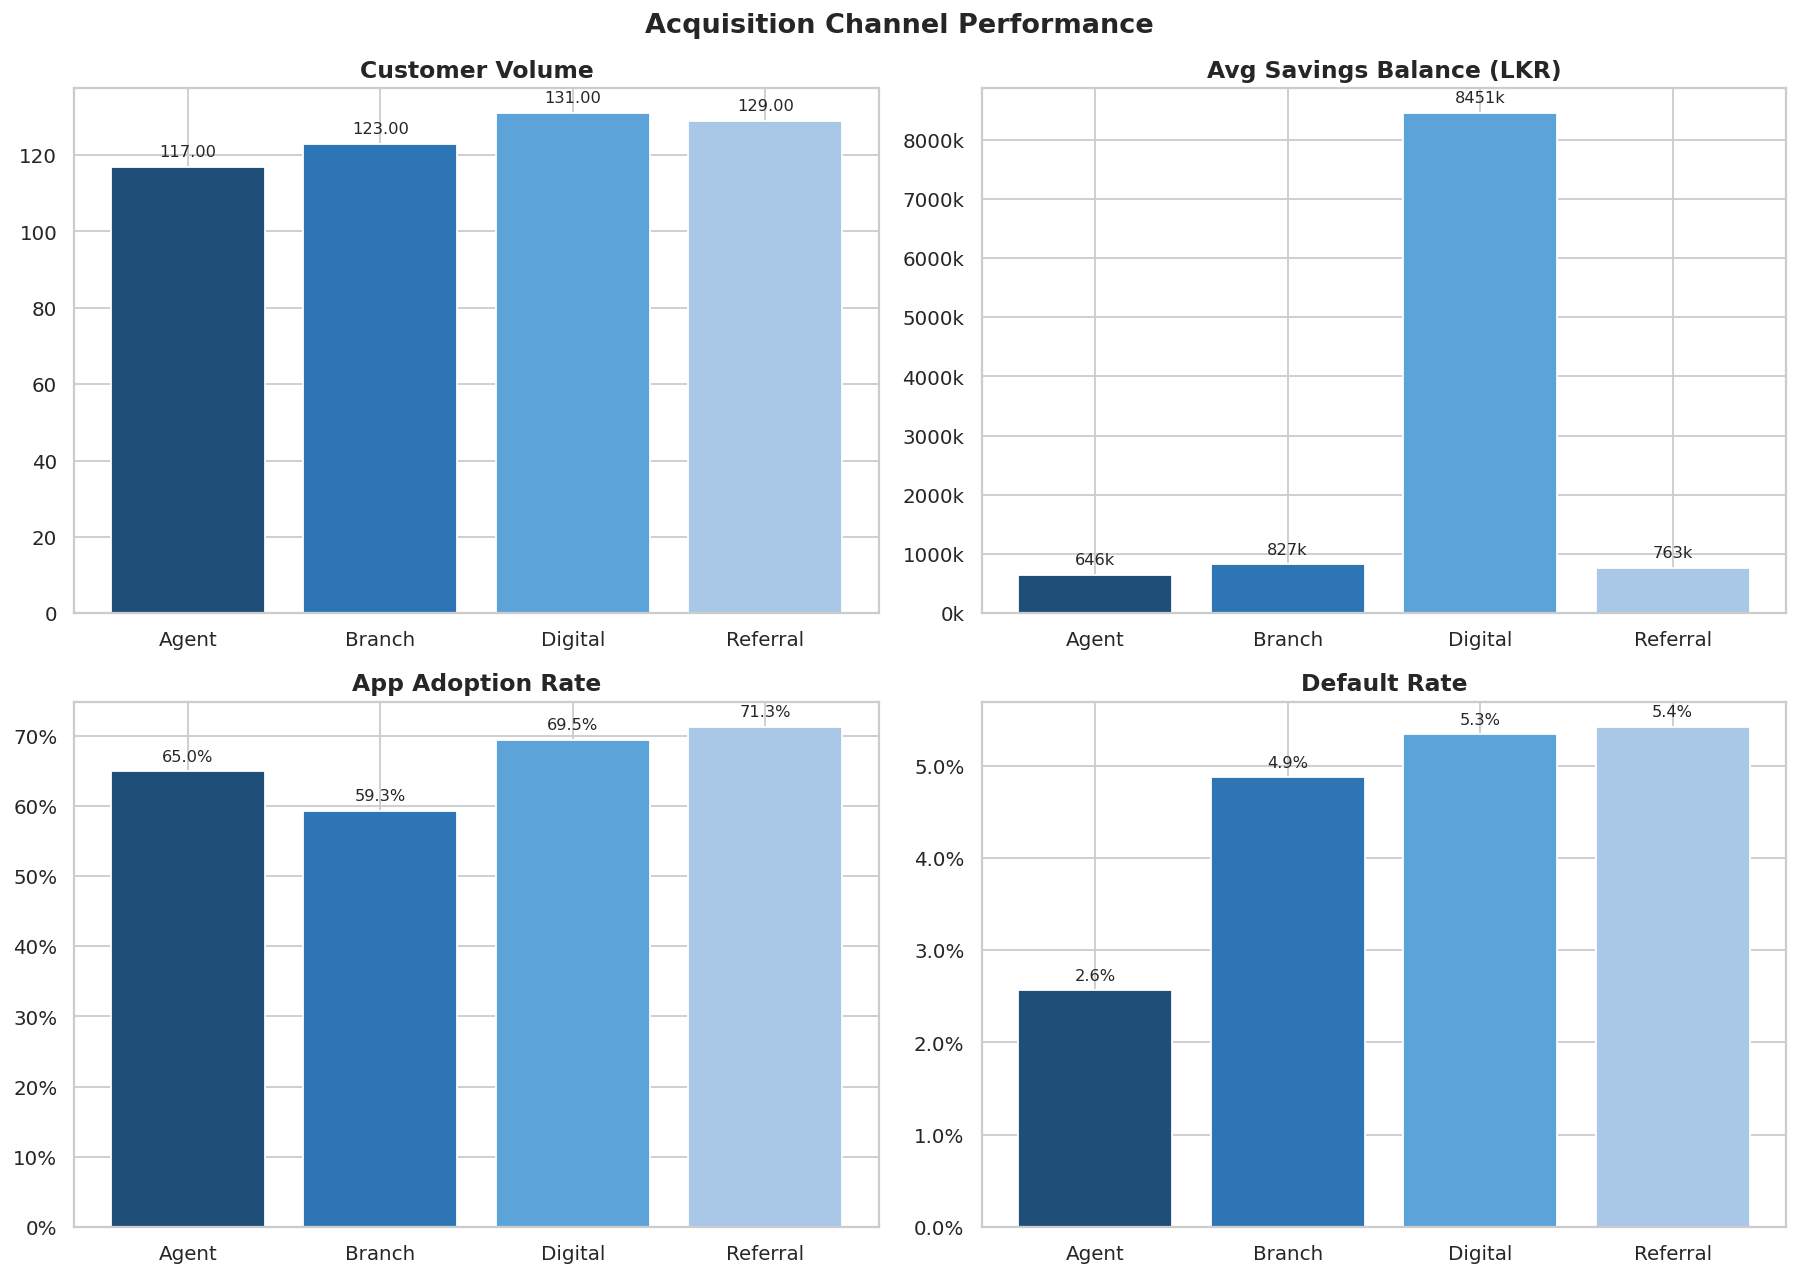

In [12]:
ch_perf = df.groupby('Acquisition_Channel').agg(
    Customers        = ('Customer_ID', 'count'),
    Avg_Savings      = ('Savings_Balance', 'mean'),
    Avg_Products     = ('Number_of_Products', 'mean'),
    App_Adoption_Pct = ('Is_App_User', 'mean'),
    Default_Rate_Pct = ('Is_Defaulted', 'mean')
).reset_index()
ch_perf['App_Adoption_Pct'] *= 100
ch_perf['Default_Rate_Pct'] *= 100

print(ch_perf.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def bar_chart(ax, x, y, title, fmt=None):
    bars = ax.bar(x, y, color=PALETTE[:len(x)], edgecolor='white')
    if fmt == 'pct':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.bar_label(bars, labels=[f'{v:.1f}%' for v in y], padding=4, fontsize=9)
    elif fmt == 'lkr':
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
        ax.bar_label(bars, labels=[f'{v/1e3:.0f}k' for v in y], padding=4, fontsize=9)
    else:
        ax.bar_label(bars, labels=[f'{v:.2f}' for v in y], padding=4, fontsize=9)
    ax.set_title(title)

bar_chart(axes[0,0], ch_perf['Acquisition_Channel'], ch_perf['Customers'],      'Customer Volume', None)
bar_chart(axes[0,1], ch_perf['Acquisition_Channel'], ch_perf['Avg_Savings'],     'Avg Savings Balance (LKR)', 'lkr')
bar_chart(axes[1,0], ch_perf['Acquisition_Channel'], ch_perf['App_Adoption_Pct'],'App Adoption Rate', 'pct')
bar_chart(axes[1,1], ch_perf['Acquisition_Channel'], ch_perf['Default_Rate_Pct'],'Default Rate', 'pct')

plt.suptitle('Acquisition Channel Performance', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 8. KYC & Compliance

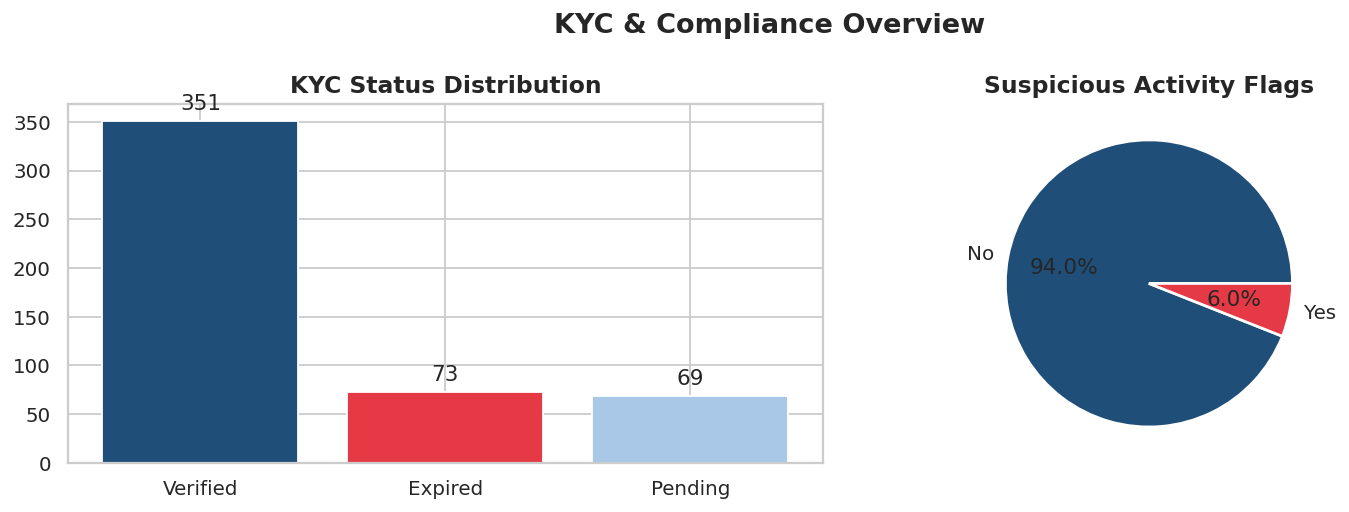

Expired KYC     : 73
Suspicious Flag : 30
PEP Flag        : 14


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

kyc = df['KYC_Status'].value_counts()
colors_kyc = [PALETTE[0] if k=='Verified' else ACCENT if k=='Expired' else PALETTE[3] for k in kyc.index]
axes[0].bar(kyc.index, kyc.values, color=colors_kyc, edgecolor='white')
axes[0].bar_label(axes[0].containers[0], padding=4)
axes[0].set_title('KYC Status Distribution')

# Suspicious activity
susp = df['Suspicious_Activity_Flag'].value_counts()
axes[1].pie(susp, labels=susp.index, autopct='%1.1f%%',
            colors=[PALETTE[0], ACCENT], wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Suspicious Activity Flags')

plt.suptitle('KYC & Compliance Overview', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

expired_kyc  = (df['KYC_Status'] == 'Expired').sum()
flagged      = (df['Suspicious_Activity_Flag'] == 'Yes').sum()
pep          = (df['PEP_Flag'] == 'Yes').sum()
print(f'Expired KYC     : {expired_kyc}')
print(f'Suspicious Flag : {flagged}')
print(f'PEP Flag        : {pep}')

## 9. Executive KPI Summary

In [14]:
total_customers   = len(df)
active_pct        = (df['Account_Status']=='Active').mean()*100
avg_products      = df['Number_of_Products'].mean()
app_adoption      = (df['Mobile_App_User']=='Yes').mean()*100
kyc_verified_pct  = (df['KYC_Status']=='Verified').mean()*100
portfolio_default = (loan_df['Loan_Repayment_Status']=='Defaulted').mean()*100
total_aum         = df['Savings_Balance'].sum() + df['FD_Amount'].sum()

kpis = {
    'Total Customers'       : f'{total_customers:,}',
    'Active Rate'           : f'{active_pct:.1f}%',
    'Avg Products / Customer': f'{avg_products:.2f}',
    'Mobile App Adoption'   : f'{app_adoption:.1f}%',
    'KYC Verified'          : f'{kyc_verified_pct:.1f}%',
    'Loan Default Rate'     : f'{portfolio_default:.1f}%',
    'Total AUM (LKR)'       : f'{total_aum:,.0f}',
}

print('=' * 45)
print('       EXECUTIVE KPI DASHBOARD')
print('=' * 45)
for k, v in kpis.items():
    print(f'  {k:<30} {v:>12}')
print('=' * 45)

       EXECUTIVE KPI DASHBOARD
  Total Customers                         500
  Active Rate                           75.4%
  Avg Products / Customer                2.50
  Mobile App Adoption                   66.4%
  KYC Verified                          70.2%
  Loan Default Rate                     10.1%
  Total AUM (LKR)                1,534,025,694


## 10. Recommendations

| # | Area | Finding | Action |
|---|------|---------|--------|
| 1 | **Retention** | Significant inactive customer base | Launch re-engagement campaigns targeting dormant >90-day app users with personalised push offers |
| 2 | **Loan Risk** | High DSR (>2×) customers show elevated default risk | Introduce pre-default alerts at 60-day delay; tighten credit policy for DSR >2× applicants |
| 3 | **Digital Shift** | Branch still preferred channel despite high app adoption | Incentivise digital migration with fee waivers and cashback for digital-only transactions |
| 4 | **Cross-Sell** | Premium segment has high savings but low insurance/FD uptake | Target Premium customers with bundled FD + Insurance offers during renewal cycles |
| 5 | **KYC Compliance** | Expired and pending KYC records pose regulatory risk | Automate KYC expiry reminders 60 days in advance; suspend high-risk accounts after 90 days |
| 6 | **Channel Quality** | Referral and Digital channels yield higher-value customers | Increase referral rewards and digital marketing budget; reduce agent commissions proportionally |
| 7 | **Portfolio Health** | Province-level default variance | Apply risk-based pricing by province; tighten loan approval thresholds in high-default regions |

## 11. Export Data for Power BI

The cleaned CSV (`fintech_cleaned.csv`) is ready for Power BI.  
Connect via **Get Data → Text/CSV** and use the pre-built measures in the `.pbip` template.